In [1]:
import pathlib

import numpy as np
from tqdm import tqdm

from efsprapy.run_analysis import process_output_ignition_probability

dir_work = pathlib.Path(r'C:\Users\IanFu\Desktop\~1_CURRENT\efsprapy\01-analysis\case_study_solve_separation')

data = dict()
for dir_project in dir_work.iterdir():
    if not dir_project.is_dir():
        continue
    if dir_project.name not in data:
        data[dir_project.name] = [list(), list()]

    for dir_case in tqdm(dir_project.iterdir()):
        if not dir_case.is_dir():
            continue
        sep, p_ig = float(dir_case.name.split('-')[1]), process_output_ignition_probability(dir_case)
        data[dir_project.name][0].append(sep)
        data[dir_project.name][1].append(p_ig)


101it [00:02, 45.88it/s]
15it [00:00, 299.83it/s]
76it [00:01, 48.24it/s]


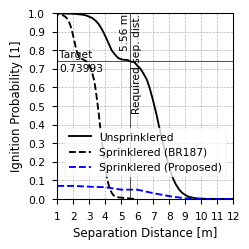

In [2]:
from efsprapy.goal_seek import sep_parallel_any_br187
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')

fig, ax = plt.subplots(figsize=(2.7, 2.7), dpi=96)

ax.set_xlabel("Separation Distance [m]")
ax.set_ylabel("Ignition Probability [1]")
ax.grid(which="both", ls="--", lw=0.5)

# br 187 084 base case
lines = dict()
lines['unsprinklered'] = ax.plot(*data['unsprinklered'], label='Unsprinklered', c='k')
y__ = np.linspace(0, 1, 100)
x__ = np.interp(y__, data['unsprinklered'][1][::-1], data['unsprinklered'][0][::-1])
lines['sprinklered_br187'] = ax.plot(list(i / 2 for i in x__), y__, label='Sprinklered (BR187)', c='k', ls='--')
lines['sprinklered_cfast'] = ax.plot(*data['sprinklered_cfast'], label='Sprinklered (Proposed)', c='b', ls='--')

# target
x_ = sep_parallel_any_br187(6, 3, 84, 12.6)
y_ = np.interp(x_, *data['unsprinklered'])
line_color = lines['unsprinklered'][0].get_color()
ax.legend(loc='center left', bbox_to_anchor=(0.015, 0.25)).set_visible(True)
ax.axvline(x_, ls="-", color=line_color, lw=0.5)
ax.text(x_ + 0.1, 1, "Required sep. dist.", color=line_color, ha="left", va="top", rotation=90, fontsize=8)
ax.text(x_ - 0., 1, f"{x_:.2f} m", color=line_color, ha="right", va="top", rotation=90, fontsize=8)
ax.axhline(y_, ls="-", color=line_color, lw=0.5)
ax.text(1.1, y_ + 0.01, "Target", color=line_color, ha="left", va="bottom", fontsize=8)
ax.text(1.1, y_ - 0.01, f"{y_:.5f}", color=line_color, ha="left", va="top", fontsize=8)

ax.set_xlim(1, 12)
ax.set_xticks(np.arange(1, 12.1, 1))
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.1))

fig.tight_layout()